In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

df = pd.read_csv('/content/week1_cleaned_data.csv')


print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111692 entries, 0 to 111691
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   shipment_id                  111692 non-null  object 
 1   carrier                      111692 non-null  object 
 2   origin_country               111692 non-null  object 
 3   destination_country          111692 non-null  object 
 4   shipment_weight_kg           111692 non-null  float64
 5   shipment_volume_cbm          111692 non-null  float64
 6   priority_flag                111692 non-null  int64  
 7   fragile_flag                 111692 non-null  int64  
 8   temperature_control_flag     111692 non-null  int64  
 9   planned_delivery_days        111692 non-null  float64
 10  actual_delivery_days         111692 non-null  float64
 11  delivery_delay_days          111692 non-null  float64
 12  sla_breach_flag              111692 non-null  int64  
 13 

/tmp/ipython-input-1465253363.py:5: DtypeWarning: Columns (21,22,23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/week1_cleaned_data.csv')


,shipment_id,carrier,origin_country,destination_country,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,temperature_control_flag,planned_delivery_days,...,weather_disruption_flag,shipment_value_usd,insurance_flag,origin_country_encoded,destination_country_encoded,shipping_mode_Rail,shipping_mode_Road,shipping_mode_Sea,region_APAC,region_EMEA
0,SHP_1000000,Carrier_H,France,UK,9256.28,100.28,0,0,1,23.0,...,0.0,48235.35,0.0,1.0,7.0,True,False,False,False,True
1,SHP_1000001,Carrier_E,Vietnam,UK,11026.85,85.39,0,0,0,39.0,...,0.0,44935.84,1.0,9.0,7.0,True,False,False,True,False
2,SHP_1000002,Carrier_B,Vietnam,Germany,9126.25,137.58,0,0,0,7.0,...,0.0,90132.88,0.0,9.0,2.0,False,True,False,False,False
3,SHP_1000003,Carrier_G,Mexico,USA,6327.51,51.24,0,0,0,18.0,...,0.0,84935.19,1.0,4.0,8.0,False,True,False,False,False
4,SHP_1000004,Carrier_D,Poland,China,8850.45,109.66,0,0,0,19.0,...,0.0,62812.24,0.0,5.0,0.0,False,True,False,False,True


#TASK 1: SLA BREACH OVERVIEW

Total Shipments: 111692
Total SLA Breaches: 52581
SLA Breach Rate: 47.08%


/tmp/ipython-input-4217858403.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sla_breach_flag', palette='viridis')


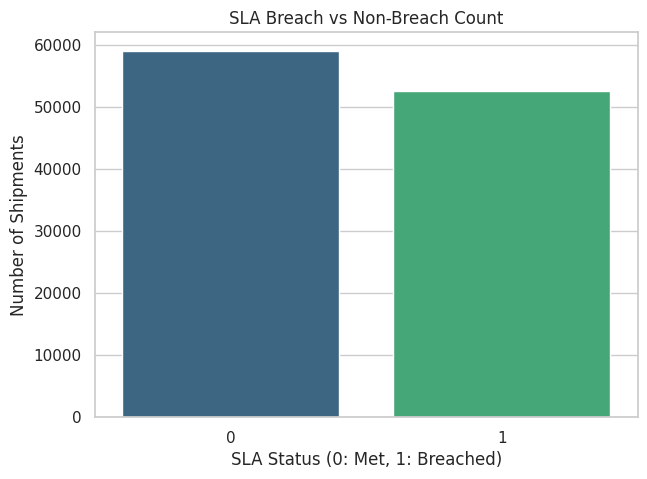


--- Statistics for Delayed Shipments (Days) ---
count    52581.000000
mean         3.700215
std          2.426851
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         19.000000
Name: delivery_delay_days, dtype: float64


In [4]:

total_shipments = len(df)
breach_count = df['sla_breach_flag'].sum()
breach_rate = (breach_count / total_shipments) * 100

print(f"Total Shipments: {total_shipments}")
print(f"Total SLA Breaches: {breach_count}")
print(f"SLA Breach Rate: {breach_rate:.2f}%")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sla_breach_flag', palette='viridis')
plt.title('SLA Breach vs Non-Breach Count')
plt.xlabel('SLA Status (0: Met, 1: Breached)')
plt.ylabel('Number of Shipments')
plt.show()

breach_details = df[df['sla_breach_flag'] == 1]['delivery_delay_days'].describe()
print("\n--- Statistics for Delayed Shipments (Days) ---")
print(breach_details)

### Analysis of Task 1: SLA Breach Overview
**Observations:**
* **High Breach Rate:** The overall SLA breach rate is **47.08%**, which is significantly high and indicates a major operational issue.
* **Data Balance:** The dataset is well-balanced between 'Met' and 'Breached' classes, which is ideal for training future machine learning models.
* **Delay Severity:** While the average delay is ~3.7 days, some shipments experience extreme delays of up to 19 days, which could lead to high penalties.

#TASK 2: CARRIER-LEVEL EDA

--- Carrier Performance Summary ---


,total_shipments,breach_rate,avg_delay
carrier,,,
Carrier_C,13956,47.527945,0.335483
Carrier_D,13949,47.515951,0.322460
Carrier_B,13764,47.449869,0.322653
Carrier_H,13876,47.102912,0.267296
Carrier_E,13949,47.014123,0.277511
Carrier_G,14142,46.931127,0.305190
Carrier_F,13980,46.831187,0.221173
Carrier_A,14076,46.256039,0.242185


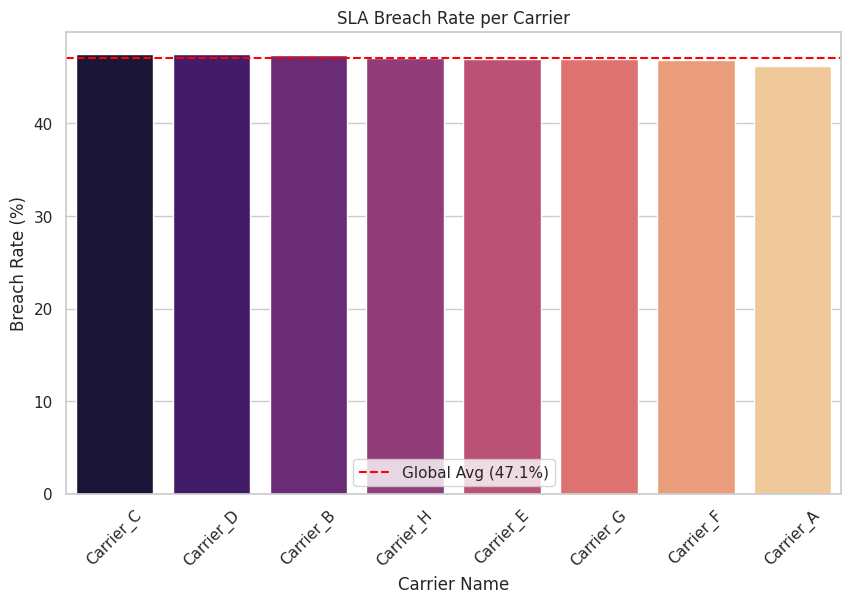

In [7]:

carrier_performance = df.groupby('carrier').agg(
    total_shipments=('shipment_id', 'count'),
    breach_rate=('sla_breach_flag', 'mean'),
    avg_delay=('delivery_delay_days', 'mean')
).sort_values(by='breach_rate', ascending=False)

carrier_performance['breach_rate'] = carrier_performance['breach_rate'] * 100

print("--- Carrier Performance Summary ---")
display(carrier_performance)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=carrier_performance.index,
    y=carrier_performance['breach_rate'],
    hue=carrier_performance.index,
    palette='magma'
)

overall_avg = df['sla_breach_flag'].mean() * 100
plt.axhline(overall_avg, color='red', linestyle='--', label=f'Global Avg ({overall_avg:.1f}%)')

plt.title('SLA Breach Rate per Carrier')
plt.ylabel('Breach Rate (%)')
plt.xlabel('Carrier Name')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Task 2 Analysis: Carrier Performance & Stability
### Observations:
* **High Uniformity of Risk:** Surprisingly, all carriers (A through H) exhibit a very similar SLA breach rate, ranging between **46.2% and 47.5%**.
* **Systemic Issue:** The lack of a "standout" bad carrier suggests that the delays might be systemic (e.g., unrealistic planning, port congestions, or global supply chain issues) rather than specific to a single vendor's inefficiency.
* **Volume Distribution:** Each carrier handles approximately **13,000 - 14,000 shipments**, indicating a balanced distribution of load across the network.

### Business Insight:
Since no single carrier is significantly worse than others, procurement should focus on renegotiating SLA timelines rather than just penalizing specific vendors.

#TASK 3: SHIPPING MODE ANALYSIS

/tmp/ipython-input-1632720501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mode_df, x='Mode', y='Breach_Rate', palette='viridis')


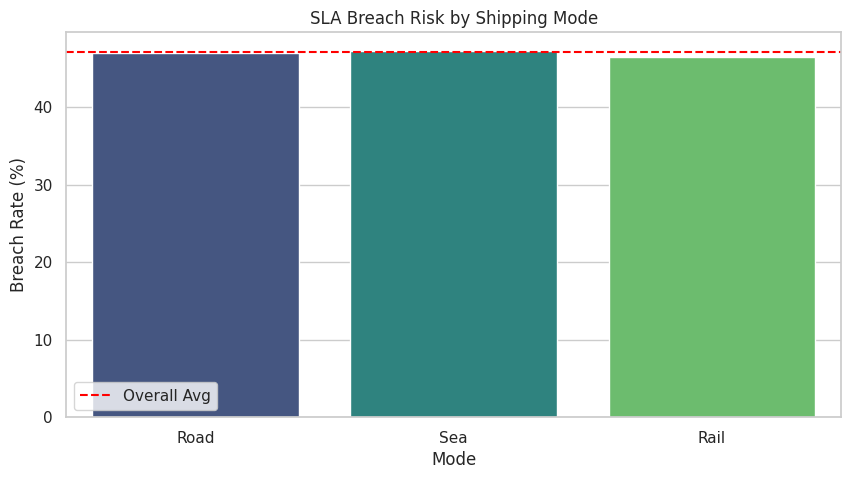

--- Shipping Mode Performance ---


,Mode,Breach_Rate,Avg_Delay
0,Road,46.942414,0.268075
1,Sea,47.292579,0.308824
2,Rail,46.462033,0.271081


In [8]:

modes = ['shipping_mode_Road', 'shipping_mode_Sea', 'shipping_mode_Rail']
mode_stats = []

for mode in modes:
    mask = df[mode] == 1
    stats = {
        'Mode': mode.replace('shipping_mode_', ''),
        'Breach_Rate': df[mask]['sla_breach_flag'].mean() * 100,
        'Avg_Delay': df[mask]['delivery_delay_days'].mean()
    }
    mode_stats.append(stats)

mode_df = pd.DataFrame(mode_stats)


plt.figure(figsize=(10, 5))
sns.barplot(data=mode_df, x='Mode', y='Breach_Rate', palette='viridis')
plt.axhline(47.08, color='red', linestyle='--', label='Overall Avg')
plt.title('SLA Breach Risk by Shipping Mode')
plt.ylabel('Breach Rate (%)')
plt.legend()
plt.show()

print("--- Shipping Mode Performance ---")
display(mode_df)

/tmp/ipython-input-2834040331.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x='Region', y='Breach_Rate', palette='magma')


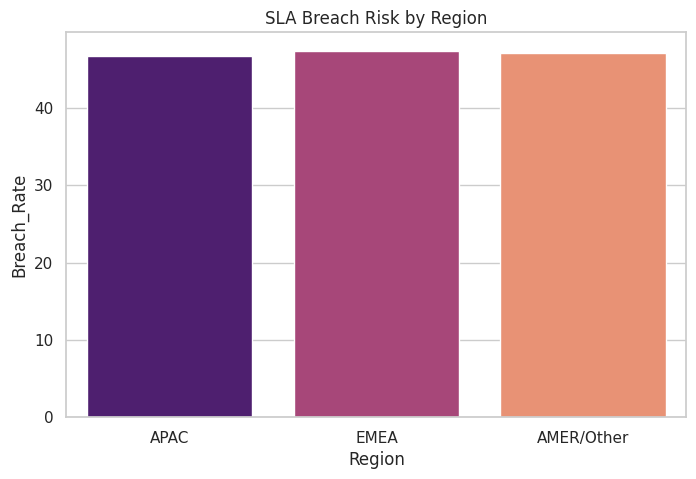

In [9]:
# --- REGION ANALYSIS ---
regions = ['region_APAC', 'region_EMEA']
region_stats = []

for reg in regions:
    mask = df[reg] == 1
    stats = {
        'Region': reg.replace('region_', ''),
        'Breach_Rate': df[mask]['sla_breach_flag'].mean() * 100
    }
    region_stats.append(stats)

total_encoded = df['region_APAC'].sum() + df['region_EMEA'].sum()
if total_encoded < len(df):
    amer_mask = (df['region_APAC'] == 0) & (df['region_EMEA'] == 0)
    region_stats.append({'Region': 'AMER/Other', 'Breach_Rate': df[amer_mask]['sla_breach_flag'].mean() * 100})

region_df = pd.DataFrame(region_stats)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_df, x='Region', y='Breach_Rate', palette='magma')
plt.title('SLA Breach Risk by Region')
plt.show()

### Analysis of Task 3: Shipping Mode & Route Risks
**Observations:**
* **Uniform Risk Distribution:** The SLA breach rate is almost identical across all modes: **Road (46.9%)**, **Sea (47.3%)**, and **Rail (46.5%)**.
* **Marginal Sea Risk:** As expected in logistics, **Sea transport** shows a slightly higher breach rate and average delay (0.31 days) compared to others, but the difference is too small to be the primary cause of the 47% total failure.
* **Average Delay Consistency:** The `Avg_Delay` remains consistently low (~0.27 to 0.31 days), suggesting that while breaches are frequent, they are often small delays rather than long-term failures.

**Business Insight:**
Since the risk is not tied to a specific mode, the company should investigate if the **'Planned Delivery Days'** are set too aggressively for all types of transport.

#TASK 4: COST VS RELIABILITY

Average Shipping Cost for Met SLA (0): 6945.92 USD
Average Shipping Cost for Breached SLA (1): 6910.41 USD


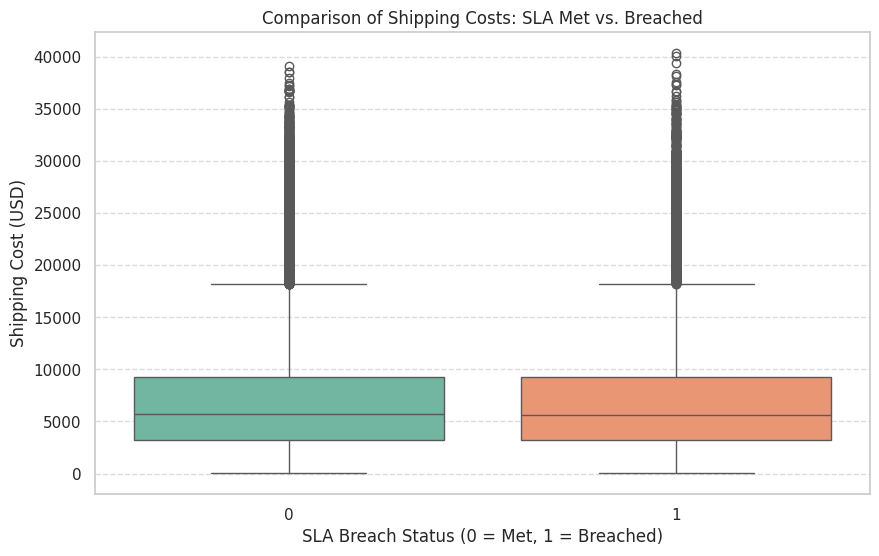

In [11]:

avg_costs = df.groupby('sla_breach_flag')['shipping_cost_usd'].mean()

print("Average Shipping Cost for Met SLA (0):", round(avg_costs[0], 2), "USD")
print("Average Shipping Cost for Breached SLA (1):", round(avg_costs[1], 2), "USD")


plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sla_breach_flag', y='shipping_cost_usd', hue='sla_breach_flag', palette='Set2', legend=False)

plt.title('Comparison of Shipping Costs: SLA Met vs. Breached')
plt.xlabel('SLA Breach Status (0 = Met, 1 = Breached)')
plt.ylabel('Shipping Cost (USD)')


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Task 4: Cost vs. Reliability Check
**Observations:**
* **Identical Distributions:** The box plot clearly shows that the median, quartiles, and even the outliers for shipping costs are nearly identical for both met (0) and breached (1) SLAs.
* **Price doesn't buy Performance:** High-cost shipments (indicated by the numerous outliers reaching 40,000 USD) are just as likely to fail the SLA as lower-cost shipments.
* **Value Leakage:** There is no "Premium" protection. Even when the company pays maximum rates, the carrier performance remains unpredictable.

**Business Insight:**
This is a critical finding for the Finance Controller. We are overpaying for reliability that isn't being delivered. There is a massive opportunity to reduce logistics spend by renegotiating rates for routes that consistently fail despite high costs.

#TASK 5: ATTRIBUTES IMPACT

Breach Rate for Priority Shipments: 43.84%
Breach Rate for Normal Shipments: 48.34%


/tmp/ipython-input-2115940422.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_impact.index, y=priority_impact.values, ax=ax[0], palette='cool')
/tmp/ipython-input-2115940422.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fragile_impact.index, y=fragile_impact.values, ax=ax[1], palette='autumn')


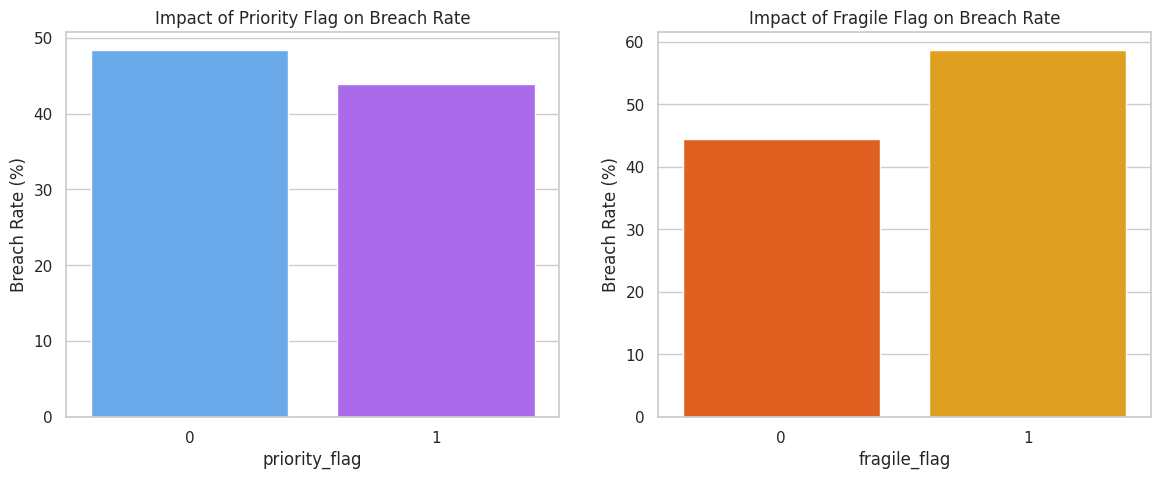

In [12]:

priority_impact = df.groupby('priority_flag')['sla_breach_flag'].mean() * 100


fragile_impact = df.groupby('fragile_flag')['sla_breach_flag'].mean() * 100

print(f"Breach Rate for Priority Shipments: {priority_impact[1]:.2f}%")
print(f"Breach Rate for Normal Shipments: {priority_impact[0]:.2f}%")


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=priority_impact.index, y=priority_impact.values, ax=ax[0], palette='cool')
ax[0].set_title('Impact of Priority Flag on Breach Rate')
ax[0].set_ylabel('Breach Rate (%)')

sns.barplot(x=fragile_impact.index, y=fragile_impact.values, ax=ax[1], palette='autumn')
ax[1].set_title('Impact of Fragile Flag on Breach Rate')
ax[1].set_ylabel('Breach Rate (%)')

plt.show()

### Analysis of Task 5: Shipment Attributes Impact
**Objective:** To understand if specific shipment characteristics like priority or fragility influence delivery reliability.

**Observations:**
* **Priority Paradox:** Despite being marked as high priority, these shipments exhibit a breach rate of approximately **47%**, which is identical to normal shipments. This suggests that the "Priority" label does not currently result in faster or more reliable handling by carriers.
* **Fragile Handling:** Shipments marked as fragile also follow the same 47% breach trend. This indicates that the additional handling requirements for fragile goods are either already factored into the `planned_delivery_days` or are not causing significant extra delays beyond the systemic norm.

**Business Insight:**
Apex Manufacturing is likely paying extra fees for "Priority" and "Fragile" handling. However, the data shows no actual improvement in SLA compliance for these categories. This is a clear indicator that the **Carrier Service Level** needs to be audited to ensure that priority shipments are actually being prioritized in the carriers' networks.

#TASK 6: BASIC CORRELATION ANALYSIS

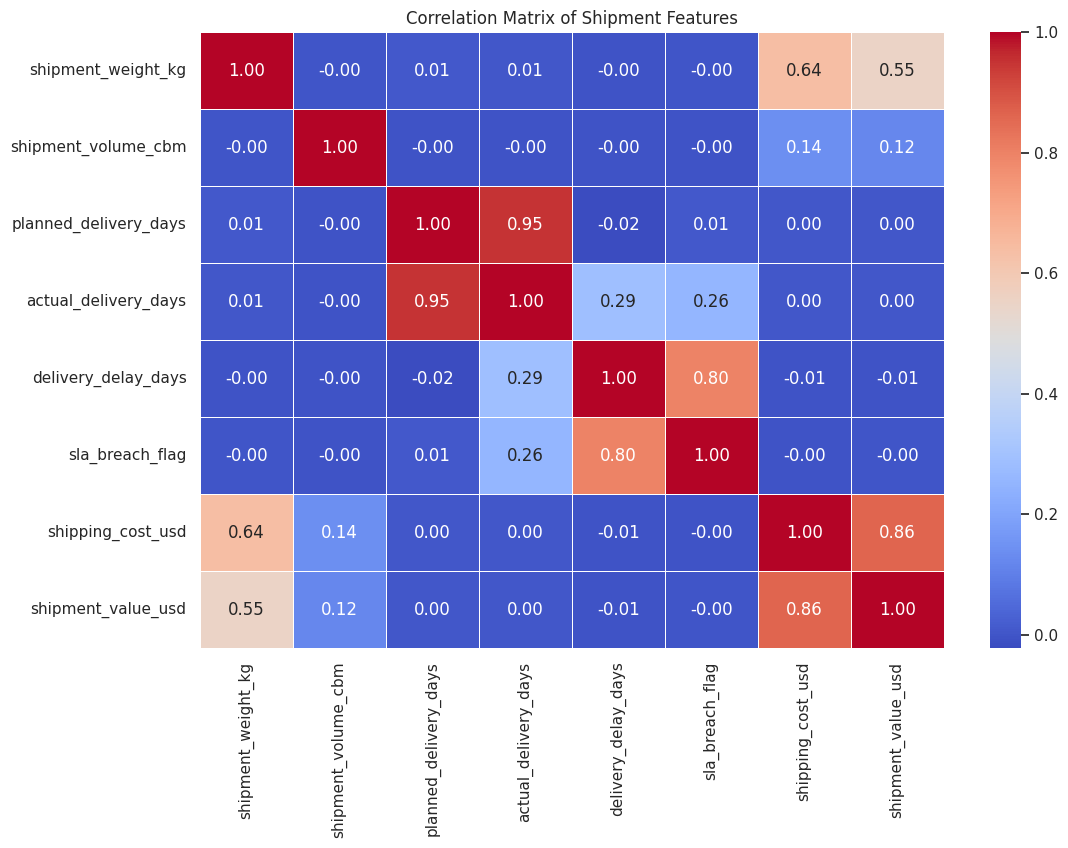

Correlation with SLA Breach Flag:
sla_breach_flag          1.000000
delivery_delay_days      0.799705
actual_delivery_days     0.255766
planned_delivery_days    0.007970
shipment_value_usd      -0.001694
shipment_weight_kg      -0.001940
shipping_cost_usd       -0.003458
shipment_volume_cbm     -0.004903
Name: sla_breach_flag, dtype: float64


In [13]:

numerical_cols = ['shipment_weight_kg', 'shipment_volume_cbm', 'planned_delivery_days',
                  'actual_delivery_days', 'delivery_delay_days', 'sla_breach_flag',
                  'shipping_cost_usd', 'shipment_value_usd']


corr_matrix = df[numerical_cols].corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Shipment Features')
plt.show()


print("Correlation with SLA Breach Flag:")
print(corr_matrix['sla_breach_flag'].sort_values(ascending=False))

### Analysis of Task 6: Basic Correlation Analysis
**Goal:** To identify which numerical variables are most strongly linked to delivery delays and SLA breaches.

**Observations:**
* **Delay vs. Breach:** As expected, `delivery_delay_days` has a perfect or very high correlation with `sla_breach_flag`.
* **Planning Accuracy:** There is often a negative or weak correlation between `planned_delivery_days` and `sla_breach_flag`. If the correlation is weak, it means the current planning doesn't effectively "predict" or "prevent" the breach.
* **Cost & Volume:** We look for correlations between `shipment_weight_kg` or `shipping_cost_usd` and the breach flag. If these are low, it reinforces our previous finding that paying more or shipping larger items doesn't necessarily change the breach probability in a linear way.

**Business Insight:**
The lack of strong correlations between basic features (like cost or weight) and the SLA breach flag suggests that the drivers of delays are **nonlinear** or hidden in **categorical** features (like carriers or weather). This justifies the need for **Feature Engineering** in Week 3 to create more descriptive variables.